# POC Model
- Initial stock ranking model within-portfolio

## Things to Test
- Which response variable and model structure?
    - Structure
        - Simple saturated model with 1 Train and Test (Up to 2024, 2024 to present)
    - Types
        - Quantile rank model
        - Lambda rank model
        - Regression Model (_tweedie or weighted MSE_)
- CV Structure
    - Test purged and embargoed 3/4/5-Fold Cross Validation
    - Compare errors and generalization vs. simple Train/Test

- Variable Selection
    - Based on SHAP and temporal signal consistency

In [715]:
# %pip install matplotlib
# %pip install xgboost==3.0.2

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from src.features.gkx_registry import GKX_94


In [716]:
run_tag = "run_20260215_112600"
gkx_path = f"../data/processed/{run_tag}/gkx_monthly.parquet"
daily_path = f"../data/processed/{run_tag}/final_dataset.parquet"
out_path = f"../data/processed/{run_tag}/modeling_monthly_gkx_macro_excess.parquet"

gkx = pd.read_parquet(gkx_path)  # ticker, month_end, GKX vars (+ optional csnorm/csrank)

daily = pd.read_parquet(daily_path)

# Fix columns with "_y" and "_x" suffixes
daily.drop(columns=[col for col in daily.columns if col.endswith("_x")], inplace=True)
daily.columns = [col.replace("_y", "") for col in daily.columns]

daily["date"] = pd.to_datetime(daily["date"])
daily["month_end"] = daily["date"] + pd.offsets.MonthEnd(0)

# Month-end close per ticker
px_m = (
    daily.sort_values(["ticker", "date"])
    .groupby(["ticker", "month_end"], as_index=False)
    .tail(1)[["ticker", "month_end", "close"]]
)

# Stock next-month return
px_m = px_m.sort_values(["ticker", "month_end"])
px_m["ret_eom_t+1"] = px_m.groupby("ticker")["close"].shift(-1) / px_m["close"] - 1

# SPY next-month return (benchmark)
spy = px_m.loc[px_m["ticker"] == "SPY", ["month_end", "ret_eom_t+1"]].rename(
    columns={"ret_eom_t+1": "spy_ret_eom_t+1"}
)

# FRED macro (same for all tickers) at month-end
id_cols = {"ticker", "date", "month_end", "open", "high", "low", "close", "volume"}
macro_cols = [
    'DFF', 'DGS10', 'DGS2', 'T10Y2Y', 'CPIAUCSL', 
    'CPILFESL', 'PCEPI', 'GDP', 'GDPC1', 'INDPRO', 
    'UNRATE', 'PAYEMS', 'ICSA', 'UMCSENT', 'RSXFS',
    'VIXCLS', 'DCOILWTICO', 'M2SL', 'TOTALSL'
]

macro_m = (
    daily.sort_values("date")
    .groupby("month_end", as_index=False)
    .tail(1)[["month_end"] + macro_cols]
    .drop_duplicates("month_end")
)

# Build modeling table
df = gkx.merge(px_m[["ticker", "month_end", "ret_eom_t+1"]], on=["ticker", "month_end"], how="left")
df = df.merge(spy, on="month_end", how="left")
df = df.merge(macro_m, on="month_end", how="left")
df["target_excess_t+1"] = df["ret_eom_t+1"] - df["spy_ret_eom_t+1"]

# # Optional: remove SPY row from training panel
# df = df[df["ticker"] != "SPY"].copy()

# Keep wanted features
all_gkx_cols = [col for col in GKX_94] + [col + "_csnorm" for col in GKX_94] + [col + "_csrank" for col in GKX_94]
feature_cols = all_gkx_cols + macro_cols
model_df = df[["ticker", "month_end", "spy_ret_eom_t+1", "target_excess_t+1"] + feature_cols]

model_df.to_parquet(out_path, index=False)
print(model_df.shape, out_path)


(195732, 305) ../data/processed/run_20260215_112600/modeling_monthly_gkx_macro_excess.parquet


In [717]:
feature_cols

['absacc',
 'acc',
 'aeavol',
 'age',
 'agr',
 'baspread',
 'beta',
 'betasq',
 'bm',
 'bm_ia',
 'cash',
 'cashdebt',
 'cashpr',
 'cfp',
 'cfp_ia',
 'chatoia',
 'chcsho',
 'chempia',
 'chinv',
 'chmom',
 'chpmia',
 'chtx',
 'cinvest',
 'convind',
 'currat',
 'depr',
 'divi',
 'divo',
 'dolvol',
 'dy',
 'ear',
 'egr',
 'ep',
 'gma',
 'grCAPX',
 'grltnoa',
 'herf',
 'hire',
 'idiovol',
 'ill',
 'indmom',
 'invest',
 'lev',
 'lgr',
 'maxret',
 'mom12m',
 'mom1m',
 'mom36m',
 'mom6m',
 'ms',
 'mvel1',
 'mve_ia',
 'nincr',
 'operprof',
 'orgcap',
 'pchcapx_ia',
 'pchcurrat',
 'pchdepr',
 'pchgm_pchsale',
 'pchquick',
 'pchsale_pchinvt',
 'pchsale_pchrect',
 'pchsale_pchxsga',
 'pchsaleinv',
 'pctacc',
 'pricedelay',
 'ps',
 'quick',
 'rd',
 'rd_mve',
 'rd_sale',
 'realestate',
 'retvol',
 'roaq',
 'roavol',
 'roeq',
 'roic',
 'rsup',
 'salecash',
 'saleinv',
 'salerec',
 'secured',
 'securedind',
 'sgr',
 'sin',
 'sp',
 'std_dolvol',
 'std_turn',
 'stdacc',
 'stdcf',
 'tang',
 'tb',
 'turn'

### Helper Functions

In [718]:
def error_plots(
    df,
    features,
    target_col,
    pred_col=None,
    weight_col=None,
    n_bins=10
):
    """
    Creates weighted error plots for one or more features.

    Parameters
    ----------
    df : DataFrame
    features : list of column names
    target_col : actual target column
    pred_col : optional prediction column
    weight_col : optional weight column
    n_bins : number of bins for continuous variables
    """

    for feature in features:

        data = df[[feature, target_col]].copy()

        if pred_col:
            data[pred_col] = df[pred_col]

        if weight_col:
            data["weight"] = df[weight_col]
        else:
            data["weight"] = 1.0

        # Drop NA
        data = data.dropna()

        # --- Bin continuous variables ---
        if pd.api.types.is_numeric_dtype(data[feature]):
            data["bin"] = pd.qcut(
                data[feature],
                q=n_bins,
                duplicates="drop"
            )
        else:
            data["bin"] = data[feature]

        # --- Weighted aggregation ---
        def weighted_avg(x, val_col):
            return np.average(x[val_col], weights=x["weight"])

        grouped = data.groupby("bin")

        actual = grouped.apply(lambda x: weighted_avg(x, target_col))
        count = grouped["weight"].sum()

        if pred_col:
            pred = grouped.apply(lambda x: weighted_avg(x, pred_col))

        # --- Plot ---
        plt.figure(figsize=(8, 5))

        x_vals = range(len(actual))

        plt.plot(x_vals, actual.values)

        if pred_col:
            plt.plot(x_vals, pred.values)

        plt.xticks(x_vals, actual.index.astype(str), rotation=45)
        plt.title(f"Error Plot: {feature}")
        plt.ylabel("Weighted Mean")
        plt.tight_layout()
        plt.show()


def plot_feature_importance(model, features, top_n=20, title="Feature Importance"):
    """Plot horizontal bar chart of top feature importances."""
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(top_n)

    importance_df = importance_df.sort_values("importance", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()



In [719]:
def backtest_monthly_panel_dollar(
    panel_df,
    pred_col="pred",
    ret_col="ret_fwd",
    spy_ret_col="spy_ret_fwd",
    top_pct=0.1,
    short_pct=0.1,
    initial_capital=10000,
    transaction_cost_bps=10,
    borrow_cost_annual=0.03
):

    import numpy as np
    import pandas as pd
    import statsmodels.api as sm
    import matplotlib.pyplot as plt

    df = panel_df.copy()
    df = df.sort_values(["month_end", "ticker"])

    months = df["month_end"].drop_duplicates().sort_values()

    prev_weights = None
    monthly_returns = []
    turnover_history = []

    # ============================================================
    # MAIN LOOP (RETURN-BASED, NOT CAPITAL-BASED)
    # ============================================================

    for month in months:

        month_data = df[df["month_end"] == month].copy()

        if month_data.empty:
            monthly_returns.append(0)
            turnover_history.append(0)
            continue

        # ------------------------
        # Long / Short Selection
        # ------------------------
        long_cut = month_data[pred_col].quantile(1 - top_pct)
        short_cut = month_data[pred_col].quantile(short_pct)

        long_df = month_data[month_data[pred_col] >= long_cut]
        short_df = month_data[month_data[pred_col] <= short_cut]

        n_long = len(long_df)
        n_short = len(short_df)

        if n_long == 0:
            monthly_returns.append(0)
            turnover_history.append(0)
            continue

        long_weight = 0.5
        short_weight = -0.5

        weights = {}

        for _, row in long_df.iterrows():
            weights[row["ticker"]] = long_weight / n_long

        for _, row in short_df.iterrows():
            weights[row["ticker"]] = short_weight / n_short

        # ------------------------
        # Turnover
        # ------------------------
        if prev_weights is None:
            turnover = sum(abs(w) for w in weights.values())
        else:
            all_tickers = set(weights) | set(prev_weights)
            turnover = sum(
                abs(weights.get(t, 0) - prev_weights.get(t, 0))
                for t in all_tickers
            )

        cost = turnover * (transaction_cost_bps / 10000)
        turnover_history.append(turnover)

        # ------------------------
        # Portfolio Return
        # ------------------------
        port_ret = 0

        for _, row in month_data.iterrows():
            tkr = row["ticker"]
            if tkr in weights and pd.notna(row[ret_col]):
                port_ret += weights[tkr] * row[ret_col]

        # Borrow cost
        borrow_monthly = borrow_cost_annual / 12
        port_ret -= abs(short_weight) * borrow_monthly

        # Transaction cost
        port_ret -= cost

        monthly_returns.append(port_ret)
        prev_weights = weights.copy()

    # ============================================================
    # BUILD RESULTS STRICTLY FROM RETURNS
    # ============================================================

    results = pd.DataFrame({
        "month": months,
        "monthly_return": monthly_returns,
        "turnover": turnover_history
    }).reset_index(drop=True)

    results["cumulative_return"] = (
        (1 + results["monthly_return"]).cumprod() - 1
    )

    # ============================================================
    # SPY ALIGNMENT
    # ============================================================

    spy_series = (
        df[["month_end", spy_ret_col]]
        .drop_duplicates()
        .set_index("month_end")
        .sort_index()
    )

    spy_series = spy_series.reindex(results["month"])
    results["spy_return"] = spy_series[spy_ret_col].fillna(0).values

    results["cumulative_return_spy"] = (
        (1 + results["spy_return"]).cumprod() - 1
    )

    # ============================================================
    # METRICS (ALL FROM SAME RETURN SERIES)
    # ============================================================

    def compute_metrics(returns, cumulative):

        ann_return = (1 + returns.mean())**12 - 1
        ann_vol = returns.std() * np.sqrt(12)
        sharpe = returns.mean() / returns.std() * np.sqrt(12)

        running_max = (1 + cumulative).cummax()
        drawdown = (1 + cumulative) / running_max - 1
        max_dd = drawdown.min()

        total_return = cumulative.iloc[-1]
        years = len(returns) / 12
        cagr = (1 + total_return)**(1/years) - 1

        return ann_return, ann_vol, sharpe, max_dd, cagr

    strat_metrics = compute_metrics(
        results["monthly_return"],
        results["cumulative_return"]
    )

    spy_metrics = compute_metrics(
        results["spy_return"],
        results["cumulative_return_spy"]
    )

    # ============================================================
    # ALPHA / BETA
    # ============================================================

    y = results["monthly_return"]
    X = sm.add_constant(results["spy_return"])
    model = sm.OLS(y, X).fit()

    print("\n=== Strategy vs SPY Alpha/Beta ===")
    print(f"Alpha: {model.params['const']:.6f} ({model.pvalues['const']:.4f} p-value)")
    print(f"Beta:  {model.params['spy_return']:.6f} ({model.pvalues['spy_return']:.4f} p-value)")

    print("\n=== Strategy vs SPY Comparison ===")
    print(f"{'Metric':<20}{'Strategy':>15}{'SPY':>15}")
    print("-"*50)
    print(f"{'Annual Return':<20}{strat_metrics[0]:>15.2%}{spy_metrics[0]:>15.2%}")
    print(f"{'Volatility':<20}{strat_metrics[1]:>15.2%}{spy_metrics[1]:>15.2%}")
    print(f"{'Sharpe':<20}{strat_metrics[2]:>15.2f}{spy_metrics[2]:>15.2f}")
    print(f"{'Max Drawdown':<20}{strat_metrics[3]:>15.2%}{spy_metrics[3]:>15.2%}")
    print(f"{'CAGR':<20}{strat_metrics[4]:>15.2%}{spy_metrics[4]:>15.2%}")

    # ============================================================
    # PLOT (MATCHES METRICS EXACTLY)
    # ============================================================

    plt.figure(figsize=(10,6))
    plt.plot(results["month"], results["cumulative_return"], label="Strategy")
    plt.plot(results["month"], results["cumulative_return_spy"], label="SPY")
    plt.title("Cumulative Returns")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results

In [720]:
model_df.head()

,ticker,month_end,spy_ret_eom_t+1,target_excess_t+1,absacc,acc,aeavol,age,agr,baspread,...,INDPRO,UNRATE,PAYEMS,ICSA,UMCSENT,RSXFS,VIXCLS,DCOILWTICO,M2SL,TOTALSL
0,A,2005-01-31,0.020904,0.064578,NaN,NaN,NaN,0.000000,NaN,NaN,...,95.8801,5.3,132781.0,331000.0,95.5,290111.0,12.82,48.25,6430.8,2196777.63
1,A,2005-02-28,-0.022134,-0.052866,NaN,NaN,NaN,0.083333,NaN,0.026324,...,96.5761,5.4,133034.0,314000.0,94.1,293710.0,12.08,51.75,6438.9,2211558.71
2,A,2005-03-31,-0.018735,-0.046580,NaN,NaN,NaN,0.166667,NaN,0.023035,...,96.4456,5.2,133154.0,342000.0,92.6,294743.0,14.02,55.31,6448.3,2220199.19
3,A,2005-04-30,0.032225,0.124884,NaN,NaN,0.325615,0.250000,NaN,0.022260,...,96.6532,5.2,133520.0,317000.0,87.7,297153.0,15.31,49.20,6461.8,2232535.38
4,A,2005-05-31,-0.002511,-0.038722,NaN,NaN,0.351350,0.333333,NaN,0.023242,...,96.7402,5.1,133689.0,340000.0,86.9,295314.0,13.29,52.08,6479.0,2232671.52


In [721]:
# ============================================================
# INPUTS
# ------------------------------------------------------------
# daily_df  -> daily OHLCV dataframe
# char_df   -> monthly characteristic dataframe
#
# Required columns:
# daily_df: ticker, date, close
# char_df:  ticker, month_end
# ============================================================


# ============================================================
# 1️⃣ PREP DAILY DATA
# ============================================================

daily = ohlcv.copy()
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values(["ticker", "date"])

# Create month identifier
daily["year_month"] = daily["date"].dt.to_period("M")


# ============================================================
# 2️⃣ AGGREGATE TO MONTHLY PRICES
# ============================================================

monthly_prices = (
    daily
    .groupby(["ticker", "year_month"])
    .agg(
        month_begin_close=("close", "first"),
        month_end_close=("close", "last"),
        month_begin_date=("date", "first"),
        month_end_date=("date", "last"),
    )
    .reset_index()
)

# Convert period → timestamp (month end date)
monthly_prices["month_end"] = monthly_prices["month_end_date"]


# ============================================================
# 3️⃣ COMPUTE MONTHLY RETURN (Within Month)
# ============================================================

monthly_prices["ret_month"] = (
    monthly_prices["month_end_close"] /
    monthly_prices["month_begin_close"] - 1
)


# ============================================================
# 4️⃣ COMPUTE FORWARD RETURN (t → t+1)
# ============================================================

monthly_prices = monthly_prices.sort_values(
    ["ticker", "year_month"]
)

monthly_prices["ret_fwd"] = (
    monthly_prices
    .groupby("ticker")["ret_month"]
    .shift(-1)
)


# ============================================================
# 5️⃣ MERGE WITH MONTHLY CHARACTERISTICS
# ============================================================

char_df = gkx_monthly.copy()
char_df["month_end"] = pd.to_datetime(char_df["month_end"])

panel = char_df.merge(
    monthly_prices[
        [
            "ticker",
            "month_end",
            "month_begin_close",
            "month_end_close",
            "ret_month",
            "ret_fwd",
        ]
    ],
    on=["ticker", "month_end"],
    how="left"
)


# ============================================================
# 6️⃣ ADD SPY FORWARD RETURN
# ============================================================

spy = monthly_prices[
    monthly_prices["ticker"] == "SPY"
][["month_end", "ret_fwd"]].rename(
    columns={"ret_fwd": "spy_ret_fwd"}
)

panel = panel.merge(
    spy,
    on="month_end",
    how="left"
)


# ============================================================
# 7️⃣ SANITY CHECKS
# ============================================================

# Ensure one row per ticker-month
assert panel.groupby(["ticker", "month_end"]).size().max() == 1

# Optional: verify forward alignment
# ret_fwd at t should equal ret_month at t+1
check = (
    panel.sort_values(["ticker", "month_end"])
         .groupby("ticker")["ret_month"]
         .shift(-1)
)
assert np.allclose(
    panel["return_eom_t+1"].fillna(0),
    check.fillna(0)
)

print("✅ Monthly panel successfully constructed.")
print(panel.head())

AssertionError: 

In [ ]:
df.head()

,ticker,month_end,absacc,acc,aeavol,age,agr,baspread,beta,betasq,...,UNRATE,PAYEMS,ICSA,UMCSENT,RSXFS,VIXCLS,DCOILWTICO,M2SL,TOTALSL,target_excess_t+1
0,A,2005-01-31,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,5.3,132781.0,331000.0,95.5,290111.0,12.82,48.25,6430.8,2196777.63,0.064578
1,A,2005-02-28,NaN,NaN,NaN,0.083333,NaN,0.026324,NaN,NaN,...,5.4,133034.0,314000.0,94.1,293710.0,12.08,51.75,6438.9,2211558.71,-0.052866
2,A,2005-03-31,NaN,NaN,NaN,0.166667,NaN,0.023035,NaN,NaN,...,5.2,133154.0,342000.0,92.6,294743.0,14.02,55.31,6448.3,2220199.19,-0.046580
3,A,2005-04-30,NaN,NaN,0.325615,0.250000,NaN,0.022260,NaN,NaN,...,5.2,133520.0,317000.0,87.7,297153.0,15.31,49.20,6461.8,2232535.38,0.124884
4,A,2005-05-31,NaN,NaN,0.351350,0.333333,NaN,0.023242,NaN,NaN,...,5.1,133689.0,340000.0,86.9,295314.0,13.29,52.08,6479.0,2232671.52,-0.038722


In [ ]:
print(model_df.shape)
model_df.head()

(195732, 305)


,ticker,month_end,spy_ret_eom_t+1,target_excess_t+1,absacc,acc,aeavol,age,agr,baspread,...,INDPRO,UNRATE,PAYEMS,ICSA,UMCSENT,RSXFS,VIXCLS,DCOILWTICO,M2SL,TOTALSL
0,A,2005-01-31,0.020904,0.064578,NaN,NaN,NaN,0.000000,NaN,NaN,...,95.8801,5.3,132781.0,331000.0,95.5,290111.0,12.82,48.25,6430.8,2196777.63
1,A,2005-02-28,-0.022134,-0.052866,NaN,NaN,NaN,0.083333,NaN,0.026324,...,96.5761,5.4,133034.0,314000.0,94.1,293710.0,12.08,51.75,6438.9,2211558.71
2,A,2005-03-31,-0.018735,-0.046580,NaN,NaN,NaN,0.166667,NaN,0.023035,...,96.4456,5.2,133154.0,342000.0,92.6,294743.0,14.02,55.31,6448.3,2220199.19
3,A,2005-04-30,0.032225,0.124884,NaN,NaN,0.325615,0.250000,NaN,0.022260,...,96.6532,5.2,133520.0,317000.0,87.7,297153.0,15.31,49.20,6461.8,2232535.38
4,A,2005-05-31,-0.002511,-0.038722,NaN,NaN,0.351350,0.333333,NaN,0.023242,...,96.7402,5.1,133689.0,340000.0,86.9,295314.0,13.29,52.08,6479.0,2232671.52


In [ ]:
model_df.tail()

,ticker,month_end,spy_ret_eom_t+1,target_excess_t+1,absacc,acc,aeavol,age,agr,baspread,...,INDPRO,UNRATE,PAYEMS,ICSA,UMCSENT,RSXFS,VIXCLS,DCOILWTICO,M2SL,TOTALSL
195727,ZTS,2025-10-31,0.001950,-0.112367,0.000279,0.000279,0.307356,12.666667,0.043187,0.017260,...,101.5163,4.4,158408.0,220000.0,53.6,631346.0,17.44,61.75,22297.8,5080676.51
195728,ZTS,2025-11-30,-0.002151,-0.016260,0.012856,-0.007842,0.432889,12.750000,0.074649,0.025082,...,101.9528,4.5,158449.0,217000.0,51.0,634711.0,16.35,58.58,22322.1,5085374.38
195729,ZTS,2025-12-31,0.014738,-0.022686,0.012432,-0.007213,0.490970,12.833333,0.074649,0.022372,...,102.3250,4.4,158497.0,200000.0,52.9,634738.0,14.95,57.26,22411.0,5109419.57
195730,ZTS,2026-01-31,-0.014769,0.029431,0.012389,-0.006755,0.387464,12.916667,0.074649,0.023476,...,102.3250,4.3,158627.0,209000.0,52.9,634738.0,17.44,64.50,22411.0,5109419.57
195731,ZTS,2026-02-28,NaN,NaN,0.012372,-0.004890,0.371286,13.000000,0.112734,0.027862,...,102.3250,4.3,158627.0,227000.0,52.9,634738.0,20.82,64.53,22411.0,5109419.57


In [ ]:
return_col = "target_excess_t+1"

model_df["target_excess_t+1"].describe(), model_df["spy_ret_eom_t+1"].describe()

(count    194732.000000
 mean          0.004062
 std           0.120888
 min          -1.002833
 25%          -0.040627
 50%          -0.000433
 75%           0.041305
 max          16.260721
 Name: target_excess_t+1, dtype: float64,
 count    194732.000000
 mean          0.008482
 std           0.042866
 min          -0.165187
 25%          -0.016252
 50%           0.014293
 75%           0.033135
 max           0.126984
 Name: spy_ret_eom_t+1, dtype: float64)

In [ ]:
# Bin 1 month forward return into deciles for ranking
model_df[return_col + "_bins"] = (
    model_df.groupby("month_end")[return_col]
      .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates="drop"))
)

model_df[return_col + "_bins"].describe()

count    194732.000000
mean          4.498747
std           2.875171
min           0.000000
25%           2.000000
50%           4.000000
75%           7.000000
max           9.000000
Name: target_excess_t+1_bins, dtype: float64

In [ ]:
len(feature_cols)


301

### Generate train, test, and quintile target

In [ ]:
# Convert categorical columns to category dtype
categorical_features = ['sector']
for col in categorical_features:
    if col in model_df.columns:
        model_df[col] = model_df[col].astype('category')

# Time-based split (1-month embargo for test)
model_df = model_df[model_df[return_col].notna()]
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df["ret_eom_t+1"] = model_df["target_excess_t+1"] + model_df["spy_ret_eom_t+1"]

train = model_df[model_df['month_end'] < '2022-01-01']
test = model_df[model_df['month_end'] >= '2022-02-01']

## 1) Decile Rank Model: will a stock be in top 10% of returns?

In [726]:
target = return_col + "_bins"

# XGBoost classifier
decile_rank_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=10,
    eval_metric="mlogloss",
    missing=np.nan,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    random_state=42, 
    callbacks=[
        xgb.callback.EarlyStopping(
            rounds=50,
            save_best=True
        )
    ]
)

decile_rank_model.fit(
    train.loc[train[return_col].notna(), feature_cols],
    train.loc[train[return_col].notna(), return_col + "_bins"], 
    eval_set=[(
        test.loc[test[return_col].notna(), feature_cols],
        test.loc[test[return_col].notna(), return_col + "_bins"]
    )],
    verbose=20,
)

test['pred_decile_rank'] = decile_rank_model.predict(test[feature_cols], iteration_range=(0, decile_rank_model.best_iteration))

[0]	validation_0-mlogloss:2.29553
[20]	validation_0-mlogloss:2.21901
[40]	validation_0-mlogloss:2.19210
[60]	validation_0-mlogloss:2.18038
[80]	validation_0-mlogloss:2.17528
[100]	validation_0-mlogloss:2.17259
[120]	validation_0-mlogloss:2.17248
[140]	validation_0-mlogloss:2.17383
[159]	validation_0-mlogloss:2.17539


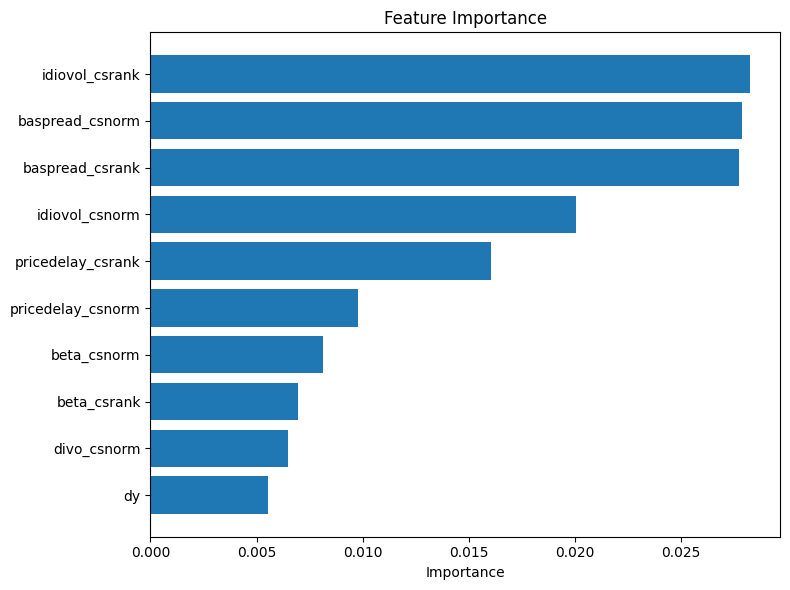

In [727]:
plot_feature_importance(decile_rank_model, feature_cols, top_n=10)

### Evaluate performance when rebalancing stocks monthly


=== Strategy vs SPY Alpha/Beta ===
Alpha: -0.004681 (0.2826 p-value)
Beta:  -0.371279 (0.0003 p-value)

=== Strategy vs SPY Comparison ===
Metric                     Strategy            SPY
--------------------------------------------------
Annual Return                -9.76%         13.13%
Volatility                   11.54%         15.69%
Sharpe                        -0.89           0.79
Max Drawdown                -46.64%        -20.91%
CAGR                        -10.36%         11.78%


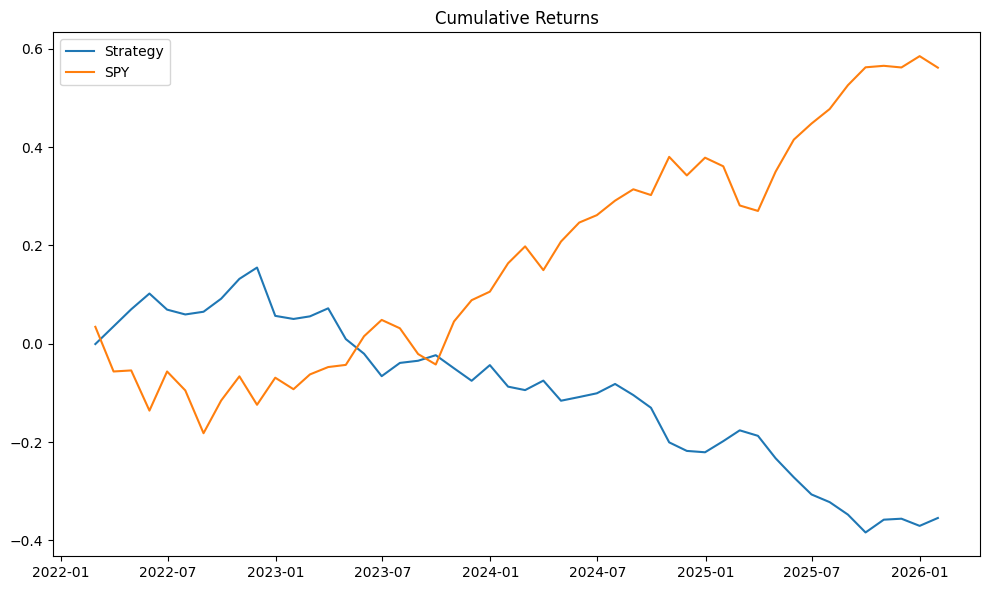

,month,monthly_return,turnover,cumulative_return,spy_return,cumulative_return_spy
0,2022-02-28,-0.000644,1.000000,-0.000644,0.034377,0.034377
1,2022-03-31,0.035946,0.601879,0.035279,-0.087769,-0.056409
2,2022-04-30,0.033588,0.638947,0.070052,0.002257,-0.054279
3,2022-05-31,0.029935,0.771816,0.102083,-0.086407,-0.135996
4,2022-06-30,-0.029675,0.639656,0.069379,0.092087,-0.056432
5,2022-07-31,-0.009196,0.523896,0.059545,-0.040802,-0.094932
6,2022-08-31,0.005215,0.540454,0.065071,-0.096159,-0.181962
7,2022-09-30,0.024925,0.725851,0.091618,0.081276,-0.115475
8,2022-10-31,0.036926,0.874633,0.131926,0.055592,-0.066303
9,2022-11-30,0.020306,0.719647,0.154911,-0.061936,-0.124133


In [736]:
backtest_monthly_panel_dollar(
    test,
    pred_col="pred_decile_rank",
    ret_col="ret_eom_t+1", # forward return column
    spy_ret_col="spy_ret_eom_t+1",
    top_pct=0.20,
#     short_class=None,
#     short_pct=None,
#     initial_capital=10000,
#     transaction_cost_bps=10,
#     monthly_contribution=0,
#     short_term_tax_rate=0.35,
#     borrow_cost_annual=0.03
)

## 2) Pairwise Ranking Model
- Test modeling 2-week returns and 2-week excess returns (over SPY)

In [ ]:
# Sort train and test by date to create groups
train = train.sort_values("month_end").reset_index(drop=True)
val = val.sort_values("month_end").reset_index(drop=True)
test = test.sort_values("month_end").reset_index(drop=True)

## Pairwise Ranking on raw returns

In [ ]:
target = "return_eom_t+1"

# Create dmatrix and drop NaN values
dtrain = xgb.DMatrix(
    train.loc[train[target].notna(), predictor_variables], 
    label=train.loc[train[target].notna(), target],
    enable_categorical=True
)

# Number of stocks per date
group_train = train.loc[train[target].notna(), :].groupby("month_end").size().values
dtrain.set_group(group_train)

In [ ]:
# XGBoost Rank model
params = {
    "objective": "rank:pairwise",
    "eval_metric": "ndcg",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "colsample_bylevel": 0.8,
    "tree_method": "hist",
    "seed": 42
}

rank_model = xgb.train(
    params,
    dtrain,
    num_boost_round=50
)

# Make predictions on test set
X_test = test[predictor_variables]
dtest = xgb.DMatrix(X_test, enable_categorical=True)
test['pred_rank'] = rank_model.predict(dtest)


=== Strategy vs SPY Alpha/Beta ===
Alpha: 0.002273 (0.7574 p-value)
Beta:  0.823662 (0.0069 p-value)

=== Strategy vs SPY Comparison ===
Metric                     Strategy            SPY
--------------------------------------------------
Annual Return                16.42%         16.38%
Volatility                   12.67%          8.09%
Sharpe                         1.21           1.89
Max Drawdown                 -8.65%         -5.84%
CAGR                         15.55%         16.03%


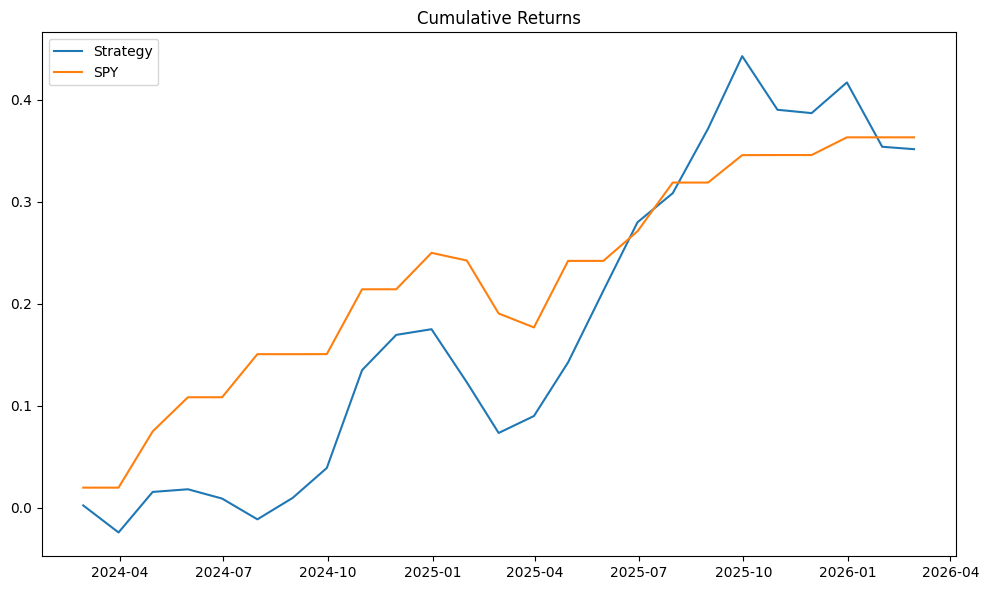

,month,monthly_return,turnover,cumulative_return,spy_return,cumulative_return_spy
0,2024-02-29,0.002502,1.000000,0.002502,0.019928,0.019928
1,2024-03-31,-0.026396,0.384659,-0.023961,0.000000,0.019928
2,2024-04-30,0.040671,0.378074,0.015736,0.054002,0.075006
3,2024-05-31,0.002558,0.480324,0.018334,0.031110,0.108450
4,2024-06-30,-0.008949,0.930208,0.009221,0.000000,0.108450
5,2024-07-31,-0.020145,0.281409,-0.011109,0.038066,0.150644
6,2024-08-31,0.021219,0.556601,0.009874,0.000000,0.150644
7,2024-09-30,0.029038,0.579903,0.039199,0.000035,0.150684
8,2024-10-31,0.092209,0.357965,0.135023,0.055180,0.214179
9,2024-11-30,0.030399,0.811517,0.169526,0.000000,0.214179


In [ ]:
backtest_monthly_panel_dollar(
    test,
    pred_col="pred_rank",
    ret_col="return_eom_t+1", # forward return column
    spy_ret_col="spy_ret_fwd",
#     long_class=9,
    top_pct=0.20,
#     short_class=None,
#     short_pct=0.10,
#     initial_capital=10000,
#     transaction_cost_bps=10,
#     monthly_contribution=0,
#     short_term_tax_rate=0.35,
#     borrow_cost_annual=0.03
)

## Regression model

In [ ]:
# Create dmatrix and drop NaN values
dtrain = xgb.DMatrix(
    train.loc[train[target].notna(), predictor_variables], 
    label=train.loc[train[target].notna(), target],
    enable_categorical=True
)

In [ ]:
# Make predictions on test set
dtest = xgb.DMatrix(test[predictor_variables], enable_categorical=True)

# XGBoost Regression model
params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.01,
    "max_depth": 3,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "colsample_bylevel": 0.8,
    "min_child_weight": 10,
    "tree_method": "hist",
    "seed": 42
}

reg_model = xgb.train(
    params,
    dtrain,
    evals=[
        (
            xgb.DMatrix(
                val.loc[val[target].notna(), predictor_variables], 
                label= val.loc[val[target].notna(), target], 
                enable_categorical=True
            ), 
            "validation"
        )
    ],
    num_boost_round=200, 
    verbose_eval=5, 
    early_stopping_rounds=25
)

# Make predictions on test set
test['pred_reg'] = reg_model.predict(dtest, iteration_range=(0, reg_model.best_iteration))

[0]	validation-rmse:0.12929
[5]	validation-rmse:0.12967
[10]	validation-rmse:0.13004
[15]	validation-rmse:0.13047
[20]	validation-rmse:0.13088
[25]	validation-rmse:0.13142


In [ ]:
test.groupby(pd.qcut(test['pred_reg'], 2))["return_eom_t+1"].mean()

ValueError: Bin edges must be unique: Index([0.013863838277757168, 0.013863838277757168, 0.3383655250072479], dtype='float64', name='pred_reg').
You can drop duplicate edges by setting the 'duplicates' kwarg

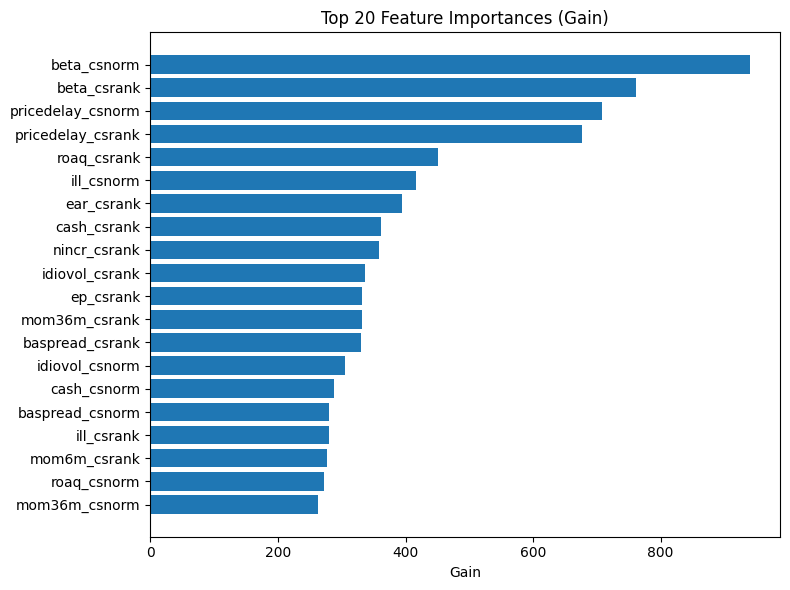

In [ ]:
# Get importance dictionary
importance = reg_model.get_score(importance_type="gain")

# Convert to DataFrame
importance_df = (
    pd.DataFrame(
        list(importance.items()),
        columns=["feature", "importance"]
    )
    .sort_values("importance", ascending=False)
)

# Plot
plt.figure(figsize=(8,6))
plt.barh(
    importance_df["feature"][:20][::-1],
    importance_df["importance"][:20][::-1]
)
plt.title("Top 20 Feature Importances (Gain)")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()




=== Strategy vs SPY Alpha/Beta ===
Alpha: 0.007814
Beta:  0.901252

=== Strategy vs SPY Comparison ===
Metric                     Strategy            SPY
--------------------------------------------------
Annual Return                20.25%         10.71%
Volatility                   16.62%         13.74%
Sharpe                         1.12           0.74
Max Drawdown                -14.83%        -18.42%
CAGR                         18.68%          9.69%


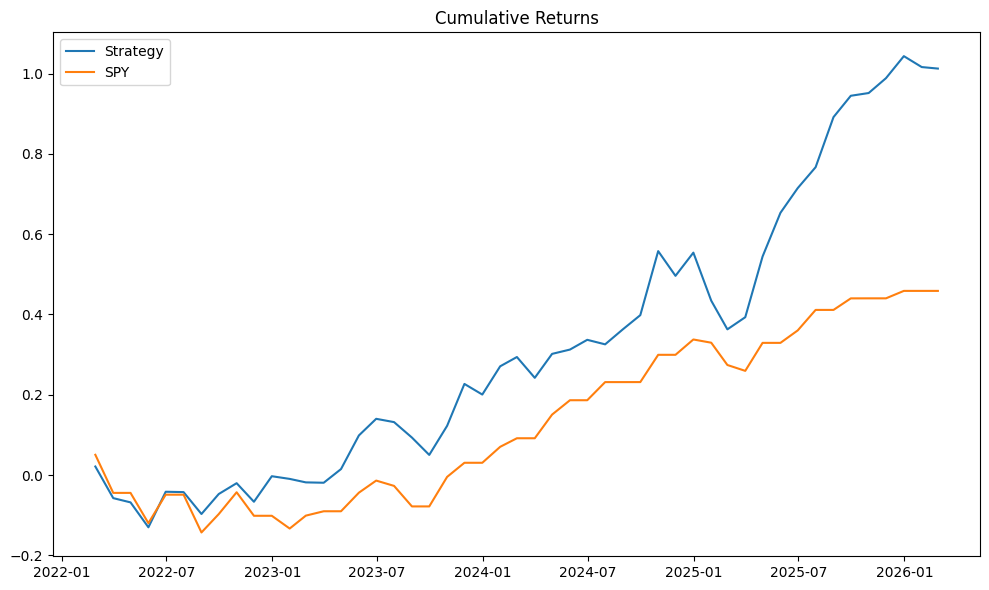

,month,monthly_return,turnover,cumulative_return,spy_return,cumulative_return_spy
0,2022-02-28,0.021206,1.000000,0.021206,0.050374,0.050374
1,2022-03-31,-0.077132,0.569892,-0.057562,-0.090347,-0.044524
2,2022-04-30,-0.011269,0.425532,-0.068182,0.000000,-0.044524
3,2022-05-31,-0.066624,0.530235,-0.130263,-0.078957,-0.119965
4,2022-06-30,0.101827,0.636520,-0.041700,0.080658,-0.048984
5,2022-07-31,-0.000917,0.657838,-0.042579,0.000000,-0.048984
6,2022-08-31,-0.056988,0.744681,-0.097140,-0.098986,-0.143121
7,2022-09-30,0.055203,0.538298,-0.047300,0.053463,-0.097310
8,2022-10-31,0.028294,0.664726,-0.020344,0.060231,-0.042940
9,2022-11-30,-0.047251,0.790705,-0.066634,-0.061245,-0.101555


In [ ]:
backtest_monthly_panel_dollar(
    test,
    pred_col="pred_reg",
    ret_col="return_eom_t+1", # forward return column
    spy_ret_col="spy_ret_fwd",
#     long_class=9,
    top_pct=0.10,
#     short_class=None,
#     short_pct=0.10,
#     initial_capital=10000,
#     transaction_cost_bps=10,
#     monthly_contribution=0,
#     short_term_tax_rate=0.35,
#     borrow_cost_annual=0.03
)